# SemRel — AfriBERTa Fine-tuning & Attention Analysis
**COS 760 Group Project — Wadalisa Molokwe**  
Fine-tunes [AfriBERTa](https://huggingface.co/castorini/afriberta_large) on the SemRel2024 Afrikaans semantic-relatedness task as a **regression** model (MSE loss, sigmoid output scaled to [0, 1]).

AfriBERTa is pretrained exclusively on African-language corpora, making it the most targeted model in our three-way comparison (Sentence-BERT / XLM-RoBERTa / AfriBERTa).

Inputs: cleaned CSVs from `02_preprocessing.ipynb`  
Outputs: `./model_outputs/afriberta/` — best checkpoint, test predictions, attention visualisations

## 1. Install & Import Dependencies

In [1]:
!pip install transformers torch scipy pandas numpy matplotlib seaborn tqdm -q tiktoken`

ERROR: Invalid requirement: 'tiktoken`': Expected semicolon (after name with no version specifier) or end
    tiktoken`
            ^


In [2]:
import os, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import spearmanr, pearsonr

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR   = './cleaned_data'
OUTPUT_DIR = './model_outputs/afriberta'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
MODEL_NAME   = 'castorini/afriberta_large'   # African-language-specific pretraining
MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 5
LR           = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_NAME}')


Device : cpu
Model  : castorini/afriberta_large


## 2. Load Cleaned Data

In [3]:
def load_split(lang: str, split: str, data_dir: str = DATA_DIR) -> pd.DataFrame:
    path = os.path.join(data_dir, f'{lang}_{split}.csv')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'File not found: {path}\nRun 02_preprocessing.ipynb first.'
        )
    return pd.read_csv(path)

train_df = load_split('afr', 'train')
dev_df   = load_split('afr', 'dev')
test_df  = load_split('afr', 'test')

print(f'Train : {len(train_df)} rows')
print(f'Dev   : {len(dev_df)} rows')
print(f'Test  : {len(test_df)} rows')
display(train_df.head(3))


Train : 300 rows
Dev   : 75 rows
Test  : 375 rows


,sentence1,sentence2,score,lang,split
0,Die sand en steen wat n dam moes vorm het net ...,Op hierdie manier kan n paar sinkkuipe langs m...,0.47,afr,train
1,Vir elke dag van die jaar is daar 'n kort aanh...,Begin elke dag met hierdie aanhaling en dra di...,0.62,afr,train
2,"Omdat lig nie om n voorwerp kan beweeg nie, vo...",Baie voorwerpe laat wel n hoeveelheid lig deur...,0.84,afr,train


## 3. Dataset & DataLoader

In [4]:
class SemRelDataset(Dataset):
    """Tokenises sentence pairs for AfriBERTa."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            str(row['sentence1']),
            str(row['sentence2']),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'score':          torch.tensor(row['score'], dtype=torch.float),
        }


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = SemRelDataset(train_df, tokenizer, MAX_LEN)
dev_ds   = SemRelDataset(dev_df,   tokenizer, MAX_LEN)
test_ds  = SemRelDataset(test_df,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train batches: {len(train_loader)} | Dev: {len(dev_loader)} | Test: {len(test_loader)}')


Train batches: 19 | Dev: 5 | Test: 24


## 4. Model Definition
AfriBERTa uses a RoBERTa backbone. We attach a regression head directly on the pooler output and apply **sigmoid** to keep predictions in [0, 1].

In [6]:
class AfriBERTaRegressor(nn.Module):
    """
    AfriBERTa (RoBERTa backbone) with a regression head for semantic relatedness.
    Uses AutoModel so the pretrained pooler weights are fully retained —
    no unexpected/missing keys at load time.
    """

    def __init__(self, model_name: str, dropout: float = 0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name, attn_implementation='eager')
        hidden_size  = self.encoder.config.hidden_size

        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid(),
        )

    def forward(self, input_ids, attention_mask, output_attentions=False):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
        )
        pooled = out.pooler_output                    # [batch, hidden]
        score  = self.regressor(pooled).squeeze(-1)   # [batch]

        if output_attentions:
            return score, out.attentions              # attentions: tuple of layer tensors
        return score


model = AfriBERTaRegressor(MODEL_NAME).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print(f'Hidden size: {model.encoder.config.hidden_size}')
print(f'Num layers : {model.encoder.config.num_hidden_layers}')
print(f'Num heads  : {model.encoder.config.num_attention_heads}')


Loading weights: 100%|██████████| 165/165 [00:00<00:00, 16316.40it/s]
XLMRobertaModel LOAD REPORT from: castorini/afriberta_large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 125,631,745
Hidden size: 768
Num layers : 10
Num heads  : 6


## 5. Optimiser & Scheduler

In [7]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total steps : {total_steps} | Warmup steps: {warmup_steps}')


Total steps : 95 | Warmup steps: 9


## 6. Training & Validation Loop

In [8]:
def evaluate(model, loader, device):
    """Return MSE, Pearson r, Spearman rho on a data split."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            lbls  = batch['score']
            preds = model(ids, mask)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())

    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    mse      = float(np.mean((preds - labels) ** 2))
    pearson  = pearsonr(preds, labels)[0]
    spearman = spearmanr(preds, labels)[0]
    return mse, pearson, spearman


In [9]:
history = {'train_loss': [], 'dev_mse': [], 'dev_pearson': [], 'dev_spearman': []}
best_spearman = -1.0
best_epoch    = -1

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        lbls  = batch['score'].to(DEVICE)

        optimizer.zero_grad()
        preds = model(ids, mask)
        loss  = criterion(preds, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    mse, pear, spear = evaluate(model, dev_loader, DEVICE)
    history['train_loss'].append(avg_loss)
    history['dev_mse'].append(mse)
    history['dev_pearson'].append(pear)
    history['dev_spearman'].append(spear)

    print(f'Epoch {epoch:02d} | Loss={avg_loss:.4f} | '
          f'Dev MSE={mse:.4f} | Pearson={pear:.4f} | Spearman={spear:.4f}')

    if spear > best_spearman:
        best_spearman = spear
        best_epoch    = epoch
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_model.pt'))
        print(f'           ↳ New best Spearman — checkpoint saved.')

print(f'\nBest Spearman: {best_spearman:.4f} at epoch {best_epoch}')


Epoch 01 | Loss=0.0581 | Dev MSE=0.0573 | Pearson=0.0010 | Spearman=-0.0500
           ↳ New best Spearman — checkpoint saved.


Epoch 02 | Loss=0.0572 | Dev MSE=0.0553 | Pearson=0.0441 | Spearman=-0.0549


Epoch 03 | Loss=0.0526 | Dev MSE=0.0551 | Pearson=0.0728 | Spearman=-0.0072
           ↳ New best Spearman — checkpoint saved.


Epoch 04 | Loss=0.0479 | Dev MSE=0.0564 | Pearson=0.0918 | Spearman=0.0010
           ↳ New best Spearman — checkpoint saved.


Epoch 05 | Loss=0.0448 | Dev MSE=0.0563 | Pearson=0.0846 | Spearman=0.0014
           ↳ New best Spearman — checkpoint saved.

Best Spearman: 0.0014 at epoch 5


## 7. Training Curves

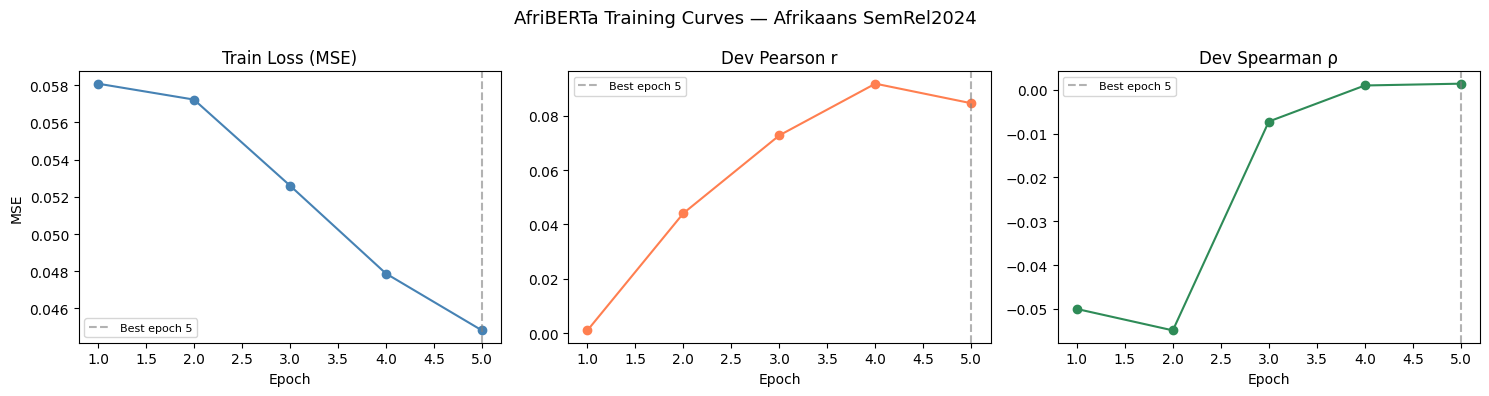

In [10]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['train_loss'], marker='o', color='steelblue')
axes[0].set_title('Train Loss (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')

axes[1].plot(epochs_range, history['dev_pearson'], marker='o', color='coral')
axes[1].set_title('Dev Pearson r'); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['dev_spearman'], marker='o', color='seagreen')
axes[2].set_title('Dev Spearman ρ'); axes[2].set_xlabel('Epoch')

for ax in axes:
    ax.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch {best_epoch}')
    ax.legend(fontsize=8)

fig.suptitle('AfriBERTa Training Curves — Afrikaans SemRel2024', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Test Set Evaluation

In [11]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_model.pt'), map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test inference'):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        preds = model(ids, mask)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['score'].numpy())

preds_arr  = np.array(all_preds)
labels_arr = np.array(all_labels)

test_mse      = float(np.mean((preds_arr - labels_arr) ** 2))
test_rmse     = float(np.sqrt(test_mse))
test_pearson  = pearsonr(preds_arr, labels_arr)[0]
test_spearman = spearmanr(preds_arr, labels_arr)[0]

print('─' * 45)
print(f'Test MSE     : {test_mse:.4f}')
print(f'Test RMSE    : {test_rmse:.4f}')
print(f'Test Pearson : {test_pearson:.4f}')
print(f'Test Spearman: {test_spearman:.4f}')
print('─' * 45)


Test inference: 100%|██████████| 24/24 [00:34<00:00,  1.45s/it]

─────────────────────────────────────────────
Test MSE     : 0.0534
Test RMSE    : 0.2311
Test Pearson : 0.1593
Test Spearman: 0.1527
─────────────────────────────────────────────


## 9. Prediction Scatter & Residuals

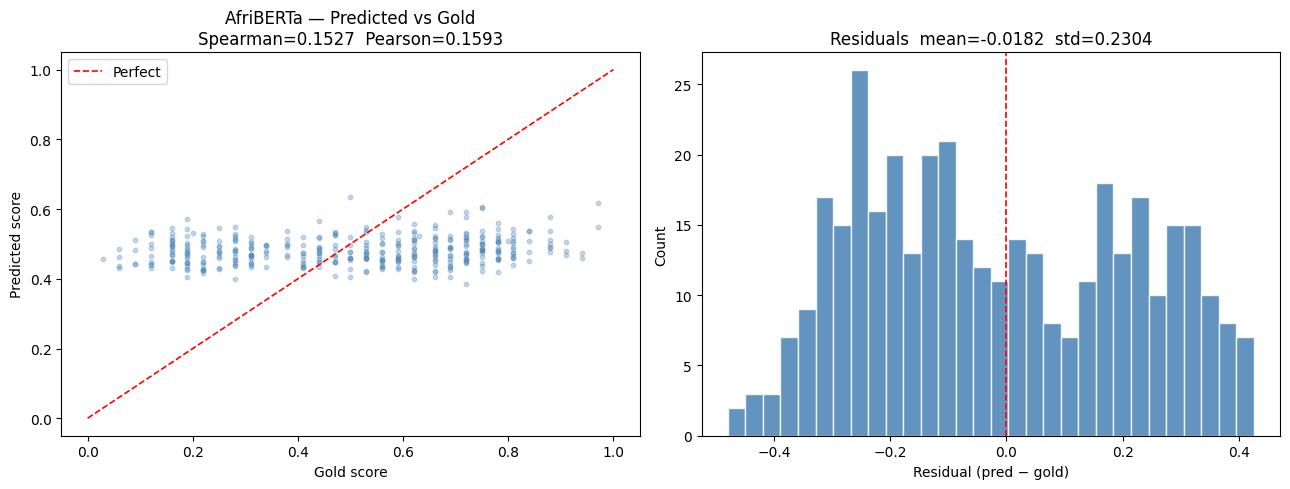

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(labels_arr, preds_arr, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0,1],[0,1], 'r--', linewidth=1.2, label='Perfect')
axes[0].set_xlabel('Gold score'); axes[0].set_ylabel('Predicted score')
axes[0].set_title(f'AfriBERTa — Predicted vs Gold\n'
                  f'Spearman={test_spearman:.4f}  Pearson={test_pearson:.4f}')
axes[0].legend()

residuals = preds_arr - labels_arr
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual (pred − gold)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals  mean={residuals.mean():.4f}  std={residuals.std():.4f}')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'predictions_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()


## 10. Attention Analysis
Extracts attention weights from the **last transformer layer** for selected sentence pairs. For each pair we visualise which tokens the model attends to most, and compare behaviour across **high-relatedness** vs **low-relatedness** pairs.

This directly addresses RQ3 from the proposal: *What linguistic patterns can be identified through attention analysis?*

In [13]:
def get_attention_for_pair(model, tokenizer, sentence1: str, sentence2: str,
                            device, max_len: int = MAX_LEN):
    """
    Returns:
        tokens   : list of token strings (including special tokens)
        attn_map : np.ndarray of shape (seq_len, seq_len) — mean over heads, last layer
        pred     : float predicted relatedness score
    """
    model.eval()
    enc = tokenizer(
        sentence1, sentence2,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    ids  = enc['input_ids'].to(device)
    mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        pred, attentions = model(ids, mask, output_attentions=True)

    # Last layer attention: shape (1, num_heads, seq_len, seq_len)
    last_layer = attentions[-1].squeeze(0)          # (num_heads, seq_len, seq_len)
    attn_map   = last_layer.mean(dim=0).cpu().numpy()  # mean over heads

    # Decode tokens; strip padding
    token_ids  = enc['input_ids'].squeeze().tolist()
    tokens     = tokenizer.convert_ids_to_tokens(token_ids)
    seq_len    = mask.squeeze().sum().item()          # actual non-pad length
    tokens     = tokens[:seq_len]
    attn_map   = attn_map[:seq_len, :seq_len]

    return tokens, attn_map, float(pred.cpu())


In [14]:
def plot_attention(tokens, attn_map, title, ax, pred_score):
    """Plot a single attention heatmap on the given axes."""
    im = ax.imshow(attn_map, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f'{title}\n(pred={pred_score:.3f})', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


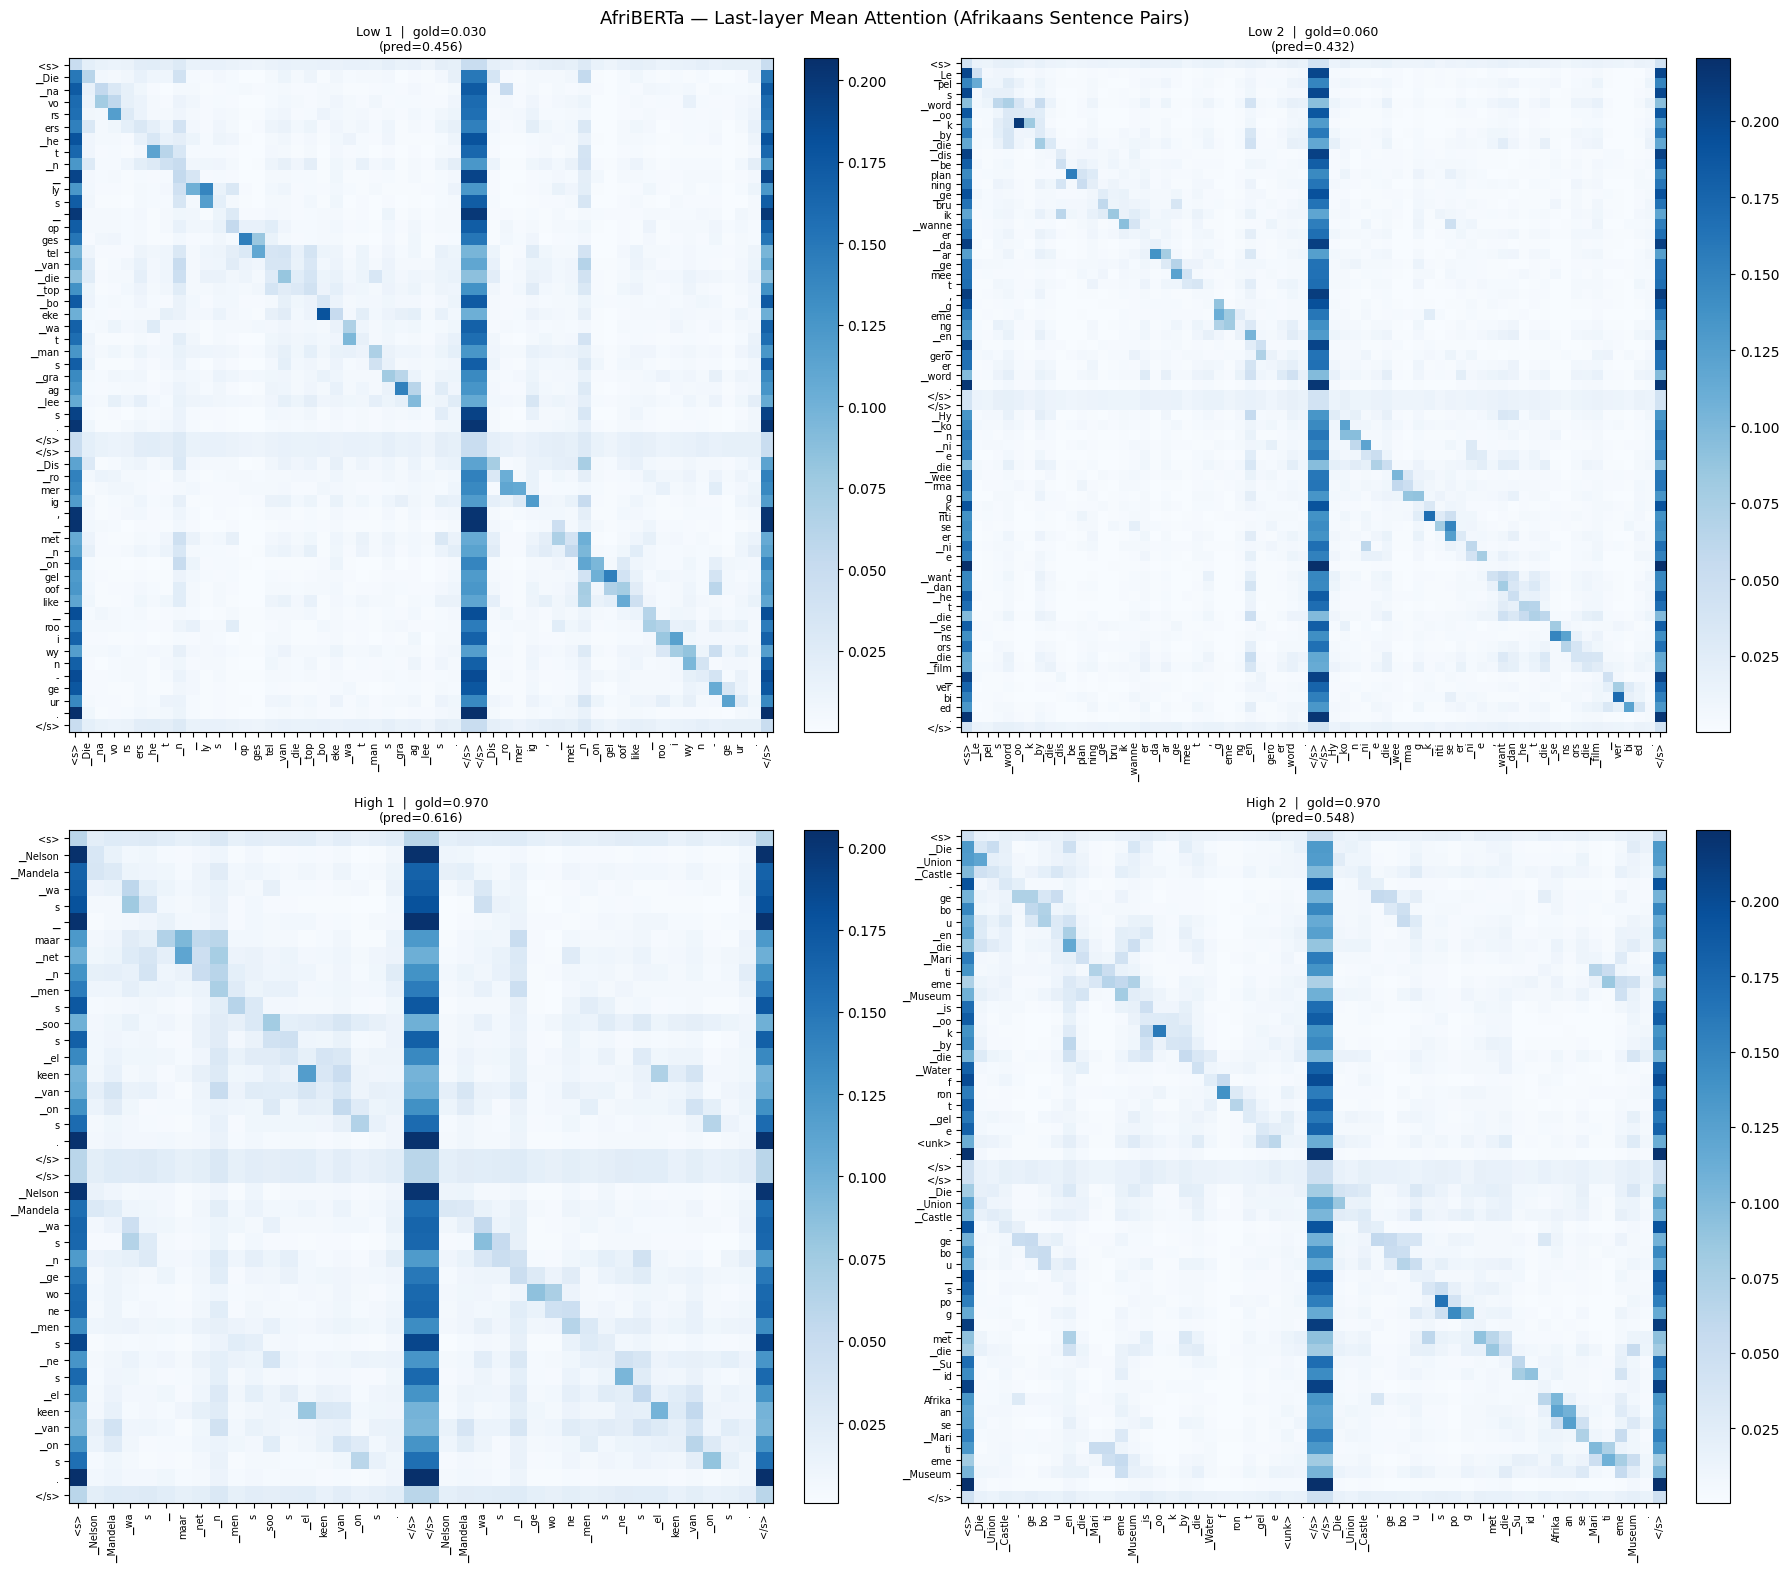

Attention maps saved.


In [15]:
# ── Select sample pairs from test set ────────────────────────────────────────
# Pick 2 high-relatedness and 2 low-relatedness pairs for contrast
test_sorted = test_df.sort_values('score')
low_pairs   = test_sorted.head(2)[['sentence1','sentence2','score']].values.tolist()
high_pairs  = test_sorted.tail(2)[['sentence1','sentence2','score']].values.tolist()
sample_pairs = low_pairs + high_pairs
labels_attn  = ['Low 1', 'Low 2', 'High 1', 'High 2']

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for ax, (s1, s2, gold), label in zip(axes, sample_pairs, labels_attn):
    tokens, attn_map, pred = get_attention_for_pair(model, tokenizer, s1, s2, DEVICE)
    plot_attention(tokens, attn_map, f'{label}  |  gold={gold:.3f}', ax, pred)

fig.suptitle('AfriBERTa — Last-layer Mean Attention (Afrikaans Sentence Pairs)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'attention_maps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Attention maps saved.')


In [16]:
# ── Token-level attention summary: which tokens get attended to most? ─────────
# For each sample pair, show the top attended tokens (row-sum over attn_map)
print('Top attended tokens per sample pair (last layer, mean over heads):\n')
for (s1, s2, gold), label in zip(sample_pairs, labels_attn):
    tokens, attn_map, pred = get_attention_for_pair(model, tokenizer, s1, s2, DEVICE)
    token_importance = attn_map.sum(axis=0)   # sum of attention received by each token
    ranked = sorted(zip(token_importance, tokens), reverse=True)
    top_tokens = [(t, round(float(w), 4)) for w, t in ranked[:8]
                  if t not in ['<s>', '</s>', '<pad>']]
    print(f'{label} (gold={gold:.3f}, pred={pred:.3f})')
    print(f'  Top tokens: {top_tokens}')
    print()


Top attended tokens per sample pair (last layer, mean over heads):

Low 1 (gold=0.030, pred=0.456)
  Top tokens: [('▁n', 1.5917), ('▁n', 1.0934), ('ig', 0.6318), ('▁van', 0.626)]

Low 2 (gold=0.060, pred=0.432)
  Top tokens: [('▁en', 1.2022), ('▁by', 0.7091), ('▁word', 0.6963), ('▁want', 0.673)]

High 1 (gold=0.970, pred=0.616)
  Top tokens: [('▁n', 1.0064), ('▁n', 0.8329), ('▁wa', 0.6444), ('▁wa', 0.6144)]

High 2 (gold=0.970, pred=0.548)
  Top tokens: [('▁en', 1.1753), ('eme', 0.7869), ('eme', 0.7817), ('▁Museum', 0.7618)]



## 11. Save Predictions

In [17]:
pred_df = test_df[['sentence1','sentence2','score']].copy()
pred_df.rename(columns={'score': 'gold_score'}, inplace=True)
pred_df['afriberta_pred'] = preds_arr

out_path = os.path.join(OUTPUT_DIR, 'test_predictions.csv')
pred_df.to_csv(out_path, index=False)
print(f'Predictions saved to: {out_path}')
display(pred_df.head(10))


Predictions saved to: ./model_outputs/afriberta\test_predictions.csv


,sentence1,sentence2,gold_score,afriberta_pred
0,Venus beweeg tot 16 November agteruit deur jou...,"Venus, die plesierplaneet, beweeg die volgende...",0.75,0.481914
1,Ons leer immers ons kinders n rein liggaam is ...,Net so is n skoon omgewing die naaste aan n sk...,0.69,0.523751
2,Ek verstaan hoekom ons Hemelse Vader n vrou ge...,Ek verstaan ook hoe n man sy vrou moet lief he...,0.66,0.478728
3,Donnalee ontvang by hierdie toekennings ook di...,Deel vir elke leerder n skoon vel papier uit.,0.19,0.503438
4,Daar is verskeie metodes waarop hierdie geld g...,Dit kan by finansiële instellings in n spaarre...,0.62,0.420255
5,Die Trust sal vooraf bystand gee vir mense uit...,Dekor word met die hand uitgesoek om by n tema...,0.31,0.440066
6,"Ons moedig ons ouers, asook ons onderwysers aa...",Daarbenewens kan 'n geneesmiddel die effek van...,0.28,0.511321
7,"Hy word n seerower wat skatte jag, of n ruimte...",Sy word n Feëprinses met towerkragte of n hond...,0.62,0.424678
8,Alternatiewelik kan dit ook veroorsaak word de...,"Dit word gewoonlik veroorsaak deur voedsel, ma...",0.66,0.491156
9,"Ons ry tussen die berge, deur klowe en oor bru...",Eers ry ons deur en oor Fontein kloof en dan L...,0.72,0.528397


## 12. Summary

In [18]:
summary = {
    'Model':          MODEL_NAME,
    'Max Seq Len':    MAX_LEN,
    'Batch Size':     BATCH_SIZE,
    'Learning Rate':  LR,
    'Epochs':         EPOCHS,
    'Best Epoch':     best_epoch,
    'Dev Spearman':   round(best_spearman, 4),
    'Test MSE':       round(test_mse, 4),
    'Test RMSE':      round(test_rmse, 4),
    'Test Pearson':   round(test_pearson, 4),
    'Test Spearman':  round(test_spearman, 4),
}

print('AfriBERTa Fine-tuning Summary')
print('=' * 42)
for k, v in summary.items():
    print(f'{k:<20}: {v}')


AfriBERTa Fine-tuning Summary
Model               : castorini/afriberta_large
Max Seq Len         : 128
Batch Size          : 16
Learning Rate       : 2e-05
Epochs              : 5
Best Epoch          : 5
Dev Spearman        : 0.0014
Test MSE            : 0.0534
Test RMSE           : 0.2311
Test Pearson        : 0.15929999947547913
Test Spearman       : 0.1527
